<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/smearing_opening_energies_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install uproot
%pip install awkward_pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 39.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import uproot
import os

import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_STATE = 42

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)
print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())

branches = [
    "RunID", "EventID",
    "GammaIndex", "NGammas",
    "X_mm", "Y_mm", "Z_mm",
    "EnergyDeposit_keV", "PreEnergy_keV", "PostEnergy_keV",
    "AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm",
]

df = tree.arrays(branches, library="pd")
df.head()

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


,RunID,EventID,GammaIndex,NGammas,X_mm,Y_mm,Z_mm,EnergyDeposit_keV,PreEnergy_keV,PostEnergy_keV,AnnihilX_mm,AnnihilY_mm,AnnihilZ_mm
0,slurm_36283167_1,43,0,3,22.533781,45.725643,-6.039716,187.380234,187.380234,0.0,3.079860,6.565360,-6.969770
1,slurm_36283167_1,43,1,3,-19.154974,-41.295967,42.954437,471.598907,471.598907,0.0,3.079860,6.565360,-6.969770
2,slurm_36283167_1,43,2,3,10.009033,22.802109,-44.240387,363.018677,363.018677,0.0,3.079860,6.565360,-6.969770
3,slurm_36283167_1,56,0,3,15.187184,14.526692,46.622974,492.708618,492.708618,0.0,-0.369778,0.324251,-4.727468
4,slurm_36283167_1,56,1,3,1.183054,-10.753192,-51.622868,304.623718,304.623718,0.0,-0.369778,0.324251,-4.727468


In [5]:
N_EVENTS = 15000

events = df[["RunID", "EventID"]].drop_duplicates()
events_subset = events.head(N_EVENTS)

df_subset = df.merge(events_subset, on=["RunID", "EventID"], how="inner")

print("Events selected:", len(events_subset))
print("Rows selected:  ", len(df_subset))
print("Events in subset:", df_subset.groupby(["RunID", "EventID"]).ngroups)

Events selected: 15000
Rows selected:   45000
Events in subset: 15000


In [6]:
LYSO_FWHM_AT_511 = 0.12
REFERENCE_ENERGY_KEV = 511.0
FWHM_TO_SIGMA = 2.35482

rng = np.random.default_rng(42)

def smear_energy(energy_keV):
    if energy_keV <= 0:
        return 0.0

    fwhm_511 = LYSO_FWHM_AT_511 * REFERENCE_ENERGY_KEV
    fwhm = fwhm_511 * np.sqrt(
        energy_keV / REFERENCE_ENERGY_KEV
    )
    sigma = fwhm / FWHM_TO_SIGMA

    smeared = rng.normal(energy_keV, sigma)
    while smeared < 0:
        smeared = rng.normal(energy_keV, sigma)

    return float(smeared)


# Apply once per hit — overwrite EnergyDeposit_keV in place so every
# downstream read (feature vector, opening-angle formula) sees the
# same smeared value, not a fresh random draw each time it's used.
df_subset["EnergyDeposit_keV"] = df_subset["EnergyDeposit_keV"].apply(smear_energy)

print(df_subset["EnergyDeposit_keV"].describe())

count    45000.000000
mean       340.716323
std        117.588856
min          9.667749
25%        257.205858
50%        355.728503
75%        436.903819
max        602.145145
Name: EnergyDeposit_keV, dtype: float64


In [8]:
#new equation
def build_event_arrays_2d(df_events):

    features_list = []
    targets_list = []
    plane_list = []

    for (run_id, event_id), event in df_events.groupby(
        ["RunID", "EventID"]
    ):

        # Order hits by decreasing energy, not GammaIndex — GammaIndex is a
        # Geant4 bookkeeping label with no physical meaning.
        event = event.sort_values(
            ["EnergyDeposit_keV", "GammaIndex"],
            ascending=[False, True]
        ).reset_index(drop=True)

        if len(event) < 3:
            continue

        event = event.iloc[:3]

        hit1 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[0].values.astype(float)

        hit2 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[1].values.astype(float)

        hit3 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[2].values.astype(float)

        v1 = hit2 - hit1
        v2 = hit3 - hit1

        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            continue

        normal = normal / normal_length

        basis_u = v1 / (
            np.linalg.norm(v1) + 1e-8
        )

        basis_v = np.cross(normal, basis_u)

        basis_v = basis_v / (
            np.linalg.norm(basis_v) + 1e-8
        )

        plane_data = np.concatenate([
            hit1,
            normal,
            basis_u,
            basis_v
        ])

        plane_list.append(plane_data)

        energy1 = float(
            event.iloc[0]["EnergyDeposit_keV"]
        )

        energy2 = float(
            event.iloc[1]["EnergyDeposit_keV"]
        )

        energy3 = float(
            event.iloc[2]["EnergyDeposit_keV"]
        )

        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        def gamma_opening_angle(e_i, e_j, e_k):
            # Physical emission angle between photons i and j, from
            # energy/momentum conservation (Fujimoto et al. 2026, Eq. 4):
            # https://doi.org/10.1038/s42005-026-02782-6
            cos_theta = (-e_i**2 - e_j**2 + e_k**2) / (2 * e_i * e_j + 1e-8)
            return np.arccos(np.clip(cos_theta, -1.0, 1.0))

        angle1 = gamma_opening_angle(energy1, energy2, energy3)  # θ between γ1, γ2
        angle2 = gamma_opening_angle(energy2, energy3, energy1)  # θ between γ2, γ3
        angle3 = gamma_opening_angle(energy3, energy1, energy2)  # θ between γ3, γ1

        features = np.concatenate([
            hit1, [energy1],
            hit2, [energy2],
            hit3, [energy3],
            [d12, d13, d23],
            [angle1, angle2, angle3]
        ])

        features_list.append(features)

        target = event[
            [
                "AnnihilX_mm",
                "AnnihilY_mm",
                "AnnihilZ_mm"
            ]
        ].iloc[0].values.astype(float)

        targets_list.append(target)

    return (
        np.array(features_list),
        np.array(targets_list),
        np.array(plane_list)
    )


X_plane2d, y_plane2d, plane_data_plane2d = build_event_arrays_2d(
    df_subset
)

print("X_plane2d shape:", X_plane2d.shape)
print("y_plane2d shape:", y_plane2d.shape)
print("plane_data_plane2d shape:", plane_data_plane2d.shape)

X_plane2d shape: (15000, 18)
y_plane2d shape: (15000, 3)
plane_data_plane2d shape: (15000, 12)


In [9]:
X_train_plane2d, X_temp_plane2d, \
y_train_plane2d, y_temp_plane2d, \
plane_train_plane2d, plane_temp_plane2d = train_test_split(
    X_plane2d,
    y_plane2d,
    plane_data_plane2d,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_val_plane2d, X_test_plane2d, \
y_val_plane2d, y_test_plane2d, \
plane_val_plane2d, plane_test_plane2d = train_test_split(
    X_temp_plane2d,
    y_temp_plane2d,
    plane_temp_plane2d,
    test_size=0.33,
    random_state=RANDOM_STATE
)

print("Training:", X_train_plane2d.shape)
print("Validation:", X_val_plane2d.shape)
print("Test:", X_test_plane2d.shape)

Training: (12000, 18)
Validation: (2010, 18)
Test: (990, 18)


In [10]:
input_scaler_plane2d = StandardScaler()

X_train_scaled_plane2d = input_scaler_plane2d.fit_transform(
    X_train_plane2d
)

X_val_scaled_plane2d = input_scaler_plane2d.transform(
    X_val_plane2d
)

X_test_scaled_plane2d = input_scaler_plane2d.transform(
    X_test_plane2d
)

In [11]:
def xyz_to_uv_plane2d(y_xyz, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    displacement = y_xyz - plane_point

    u = np.sum(
        displacement * basis_u,
        axis=1
    )

    v = np.sum(
        displacement * basis_v,
        axis=1
    )

    return np.column_stack([u, v])


y_train_uv_plane2d = xyz_to_uv_plane2d(
    y_train_plane2d,
    plane_train_plane2d
)

y_val_uv_plane2d = xyz_to_uv_plane2d(
    y_val_plane2d,
    plane_val_plane2d
)

y_test_uv_plane2d = xyz_to_uv_plane2d(
    y_test_plane2d,
    plane_test_plane2d
)

print("Training UV:", y_train_uv_plane2d.shape)
print("Validation UV:", y_val_uv_plane2d.shape)
print("Test UV:", y_test_uv_plane2d.shape)

Training UV: (12000, 2)
Validation UV: (2010, 2)
Test UV: (990, 2)


In [12]:
class Plane2DMLP(tf.keras.Model):

    def __init__(self, hidden_units=100):
        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense2 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense3 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu" #extra dense layer
        )

        self.output_layer = tf.keras.layers.Dense(2)

    def call(self, x, training=False):

        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)

        return self.output_layer(x)

In [13]:
model_plane2d = Plane2DMLP(
    hidden_units=100
)

model_plane2d.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mae",
    metrics=["mae"]
)

In [14]:
history_plane2d = model_plane2d.fit(
    X_train_scaled_plane2d,
    y_train_uv_plane2d,
    validation_data=(
        X_val_scaled_plane2d,
        y_val_uv_plane2d
    ),
    epochs=200,
    batch_size=32,
    shuffle=True
)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 6.6085 - mae: 6.6085 - val_loss: 2.5747 - val_mae: 2.5747
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.2964 - mae: 2.2964 - val_loss: 2.2335 - val_mae: 2.2335
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9549 - mae: 1.9549 - val_loss: 1.9045 - val_mae: 1.9045
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7402 - mae: 1.7402 - val_loss: 1.7578 - val_mae: 1.7578
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6161 - mae: 1.6161 - val_loss: 1.6050 - val_mae: 1.6050
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5526 - mae: 1.5526 - val_loss: 1.4811 - val_mae: 1.4811
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5284 - mae: 1.5284 - val_loss: 1.5329 - val_mae: 1.5329
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4659 - mae: 1.4659 - val_loss: 1.5290 - val_mae: 1.5290
Epoch 9/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [15]:
def uv_to_xyz_plane2d(uv, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    u = uv[:, 0]
    v = uv[:, 1]

    xyz = (
        plane_point
        + u[:, None] * basis_u
        + v[:, None] * basis_v
    )

    return xyz

In [16]:
uv_pred_plane2d = model_plane2d.predict(
    X_test_scaled_plane2d
)

xyz_pred_plane2d = uv_to_xyz_plane2d(
    uv_pred_plane2d,
    plane_test_plane2d
)

print("XYZ prediction shape:", xyz_pred_plane2d.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
XYZ prediction shape: (990, 3)


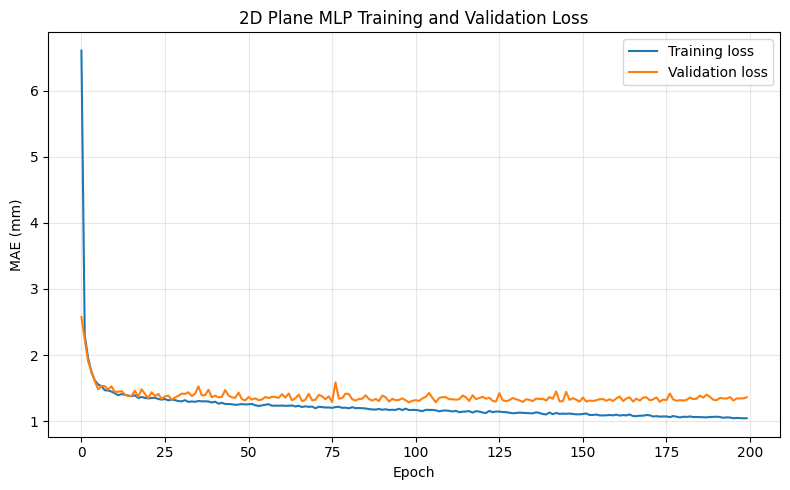

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_plane2d.history["loss"],
    label="Training loss"
)

plt.plot(
    history_plane2d.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (mm)")
plt.title("2D Plane MLP Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import r2_score
errors_plane2d = (
    xyz_pred_plane2d - y_test_plane2d
)

absolute_errors_plane2d = np.abs(
    errors_plane2d
)

x_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 0]
)

y_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 1]
)

z_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 2]
)

print("X MAE:", x_mae_plane2d, "mm")
print("Y MAE:", y_mae_plane2d, "mm")
print("Z MAE:", z_mae_plane2d, "mm")

X MAE: 1.1175912309737963 mm
Y MAE: 1.1430421937015167 mm
Z MAE: 1.0628675897969144 mm


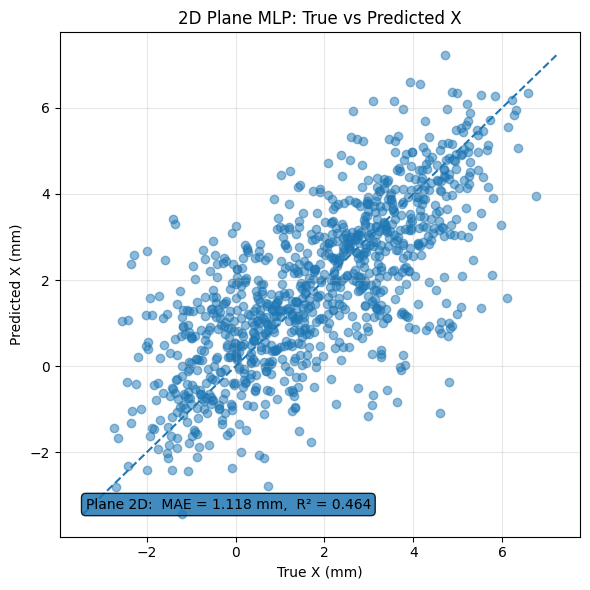

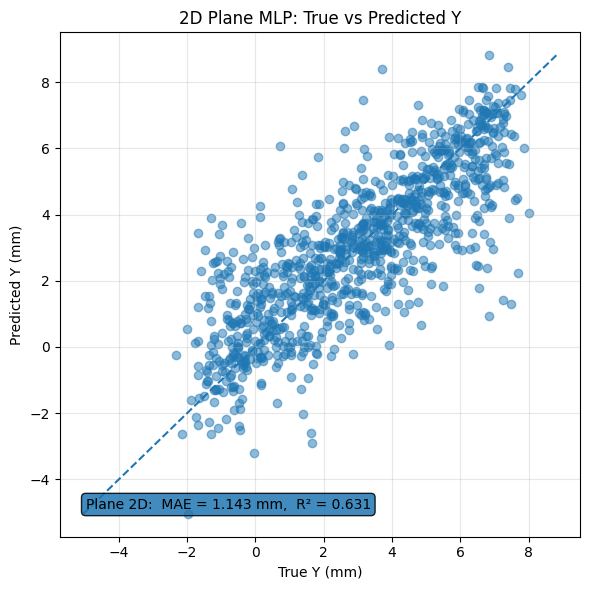

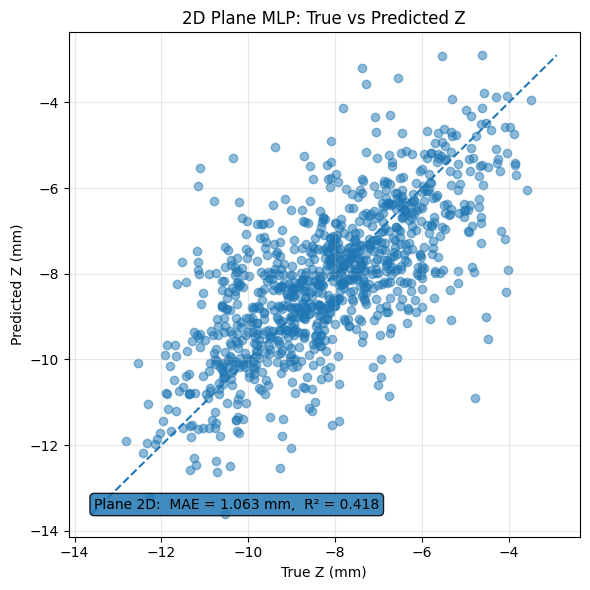

In [19]:
figures = [
    ("X", 0, x_mae_plane2d),
    ("Y", 1, y_mae_plane2d),
    ("Z", 2, z_mae_plane2d)
]

for coordinate, index, mae_val in figures:

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_plane2d[:, index],
        xyz_pred_plane2d[:, index],
        alpha=0.5
    )

    minimum = min(
        y_test_plane2d[:, index].min(),
        xyz_pred_plane2d[:, index].min()
    )

    maximum = max(
        y_test_plane2d[:, index].max(),
        xyz_pred_plane2d[:, index].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    r2_plane2d = r2_score(
        y_test_plane2d[:, index],
        xyz_pred_plane2d[:, index]
    )

    metrics_text = (
        f"Plane 2D:  MAE = {mae_val:.3f} mm,  R² = {r2_plane2d:.3f}"
    )

    plt.text(
        0.05,
        0.05,
        metrics_text,
        transform=plt.gca().transAxes,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round",
            alpha=0.85
        )
    )

    plt.xlabel(f"True {coordinate} (mm)")
    plt.ylabel(f"Predicted {coordinate} (mm)")
    plt.title(
        f"2D Plane MLP: True vs Predicted {coordinate}"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [34]:
for coordinate, index in [("X", 0), ("Y", 1), ("Z", 2)]:
    mae = np.mean(np.abs(xyz_pred_plane2d[:, index] - y_test_plane2d[:, index]))
    r2 = r2_score(y_test_plane2d[:, index], xyz_pred_plane2d[:, index])
    print(f"{coordinate}: MAE = {mae:.3f} mm, R² = {r2:.3f}")

X: MAE = 1.118 mm, R² = 0.464
Y: MAE = 1.143 mm, R² = 0.631
Z: MAE = 1.063 mm, R² = 0.418


In [20]:
model_errors_plane2d = np.linalg.norm(
    xyz_pred_plane2d - y_test_plane2d,
    axis=1
)

mean_error_plane2d = np.mean(
    model_errors_plane2d
)

median_error_plane2d = np.median(
    model_errors_plane2d
)

std_error_plane2d = np.std(
    model_errors_plane2d
)

max_error_plane2d = np.max(
    model_errors_plane2d
)

print("2D PLANE MLP PERFORMANCE")

print(f"Mean 3D error   : {mean_error_plane2d:.3f} mm")
print(f"Median 3D error : {median_error_plane2d:.3f} mm")
print(f"Std 3D error    : {std_error_plane2d:.3f} mm")
print(f"Maximum error   : {max_error_plane2d:.3f} mm")

print()

print(f"X MAE           : {x_mae_plane2d:.3f} mm")
print(f"Y MAE           : {y_mae_plane2d:.3f} mm")
print(f"Z MAE           : {z_mae_plane2d:.3f} mm")

print()


print("PLANE CONSTRAINT")

plane_points = plane_test_plane2d[:, 0:3]
plane_normals = plane_test_plane2d[:, 3:6]

plane_distances_plane2d = np.abs(
    np.sum(
        (xyz_pred_plane2d - plane_points)
        * plane_normals,
        axis=1
    )
)

print(
    f"Mean plane distance   : "
    f"{np.mean(plane_distances_plane2d):.6f} mm"
)

print(
    f"Median plane distance : "
    f"{np.median(plane_distances_plane2d):.6f} mm"
)

print(
    f"Maximum plane distance: "
    f"{np.max(plane_distances_plane2d):.6f} mm"
)

2D PLANE MLP PERFORMANCE
Mean 3D error   : 2.207 mm
Median 3D error : 1.980 mm
Std 3D error    : 1.304 mm
Maximum error   : 7.540 mm

X MAE           : 1.118 mm
Y MAE           : 1.143 mm
Z MAE           : 1.063 mm

PLANE CONSTRAINT
Mean plane distance   : 0.000000 mm
Median plane distance : 0.000000 mm
Maximum plane distance: 0.000000 mm


In [21]:
mean_position_plane2d = np.mean(
    y_train_plane2d,
    axis=0
)

print(
    "Mean annihilation position (train):",
    mean_position_plane2d
)

mean_predictions_plane2d = np.tile(
    mean_position_plane2d,
    (len(y_test_plane2d), 1)
)

mean_errors_plane2d = np.linalg.norm(
    mean_predictions_plane2d - y_test_plane2d,
    axis=1
)

baseline_mean_plane2d = np.mean(
    mean_errors_plane2d
)

baseline_median_plane2d = np.median(
    mean_errors_plane2d
)

print(
    "\nMean-position baseline — mean 3D error:",
    baseline_mean_plane2d,
    "mm"
)

print(
    "Mean-position baseline — median 3D error:",
    baseline_median_plane2d,
    "mm"
)

improvement_plane2d = (
    (baseline_mean_plane2d - mean_error_plane2d)
    / baseline_mean_plane2d
    * 100
)

print(
    f"\n2D plane MLP mean 3D error: "
    f"{mean_error_plane2d:.3f} mm"
)

print(
    f"Baseline mean 3D error: "
    f"{baseline_mean_plane2d:.3f} mm"
)

print(
    f"Improvement over baseline: "
    f"{improvement_plane2d:.1f}%"
)

Mean annihilation position (train): [ 1.82516059  3.00046503 -8.14236138]

Mean-position baseline — mean 3D error: 3.5481860379629215 mm
Mean-position baseline — median 3D error: 3.6685539241921443 mm

2D plane MLP mean 3D error: 2.207 mm
Baseline mean 3D error: 3.548 mm
Improvement over baseline: 37.8%


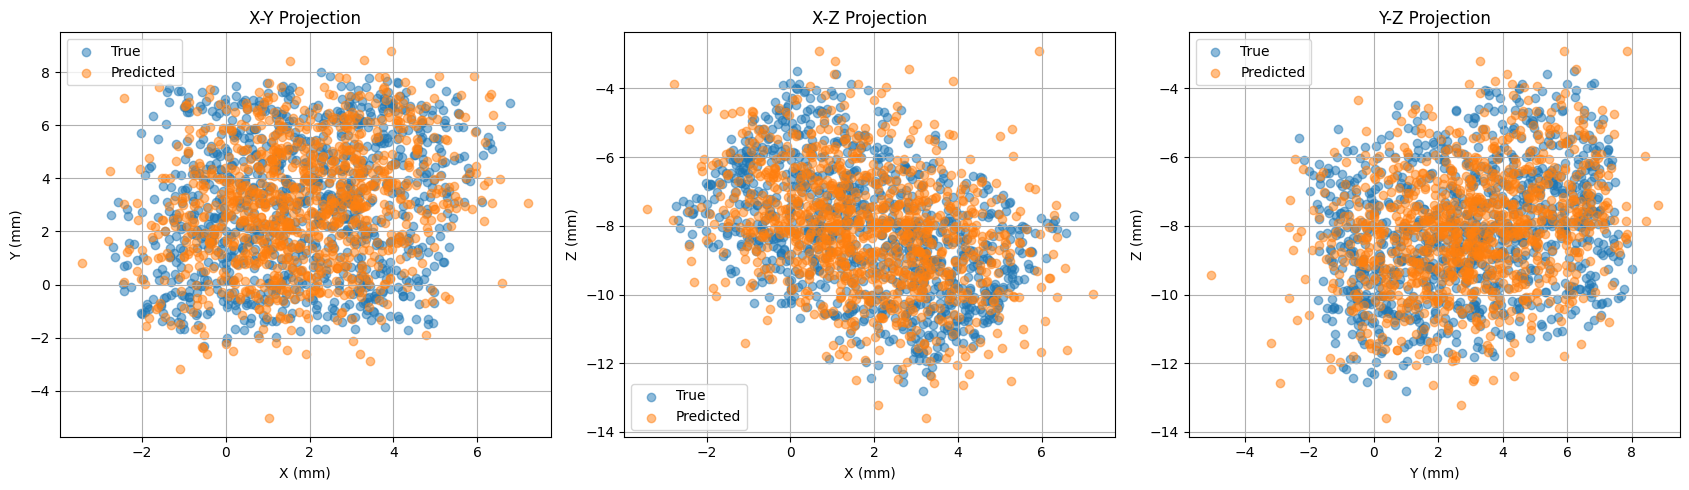

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
projections = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, xname, yname) in zip(axes, projections):
    ax.scatter(y_test_plane2d[:, i], y_test_plane2d[:, j], alpha=0.5, label="True")
    ax.scatter(xyz_pred_plane2d[:, i], xyz_pred_plane2d[:, j], alpha=0.5, label="Predicted")
    ax.set_xlabel(f"{xname} (mm)")
    ax.set_ylabel(f"{yname} (mm)")
    ax.set_title(f"{xname}-{yname} Projection")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

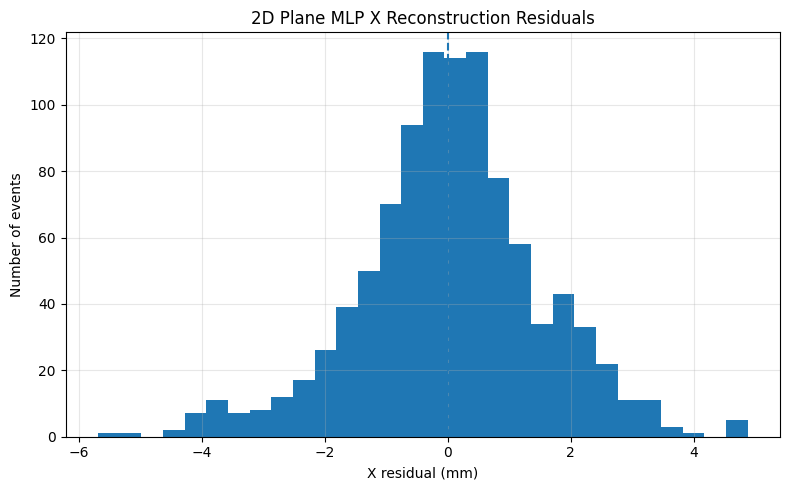

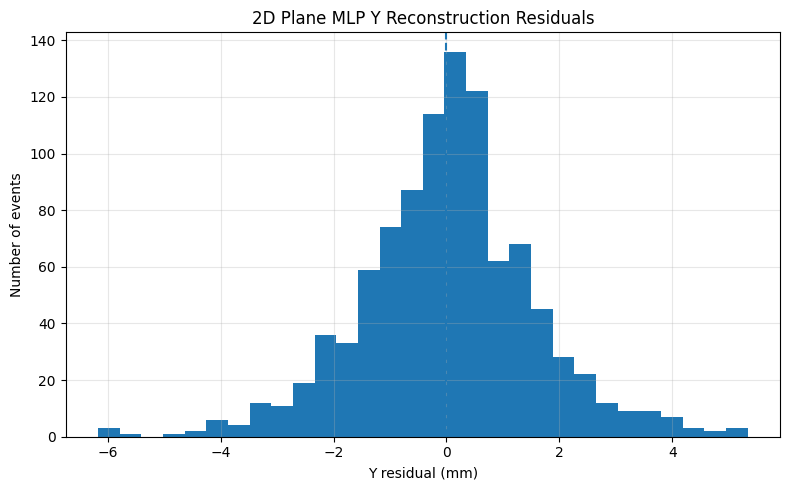

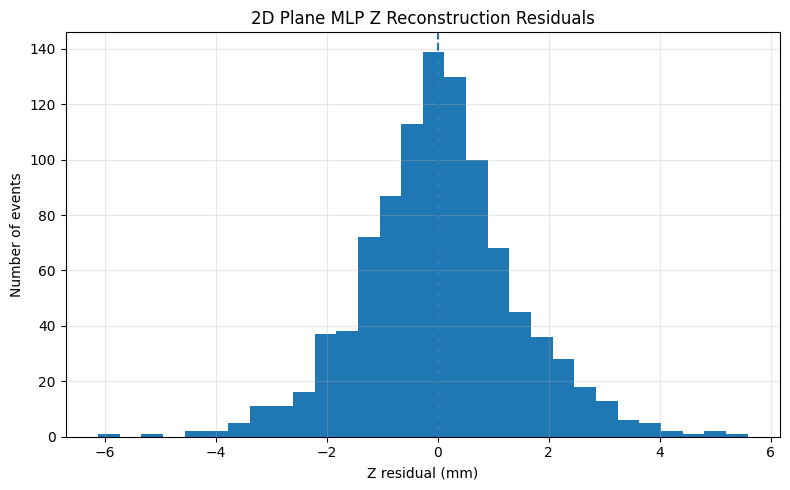

In [23]:
for coordinate, index in [
    ("X", 0),
    ("Y", 1),
    ("Z", 2)
]:

    plt.figure(figsize=(8, 5))

    plt.hist(
        errors_plane2d[:, index],
        bins=30
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(f"{coordinate} residual (mm)")
    plt.ylabel("Number of events")
    plt.title(
        f"2D Plane MLP {coordinate} Reconstruction Residuals"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

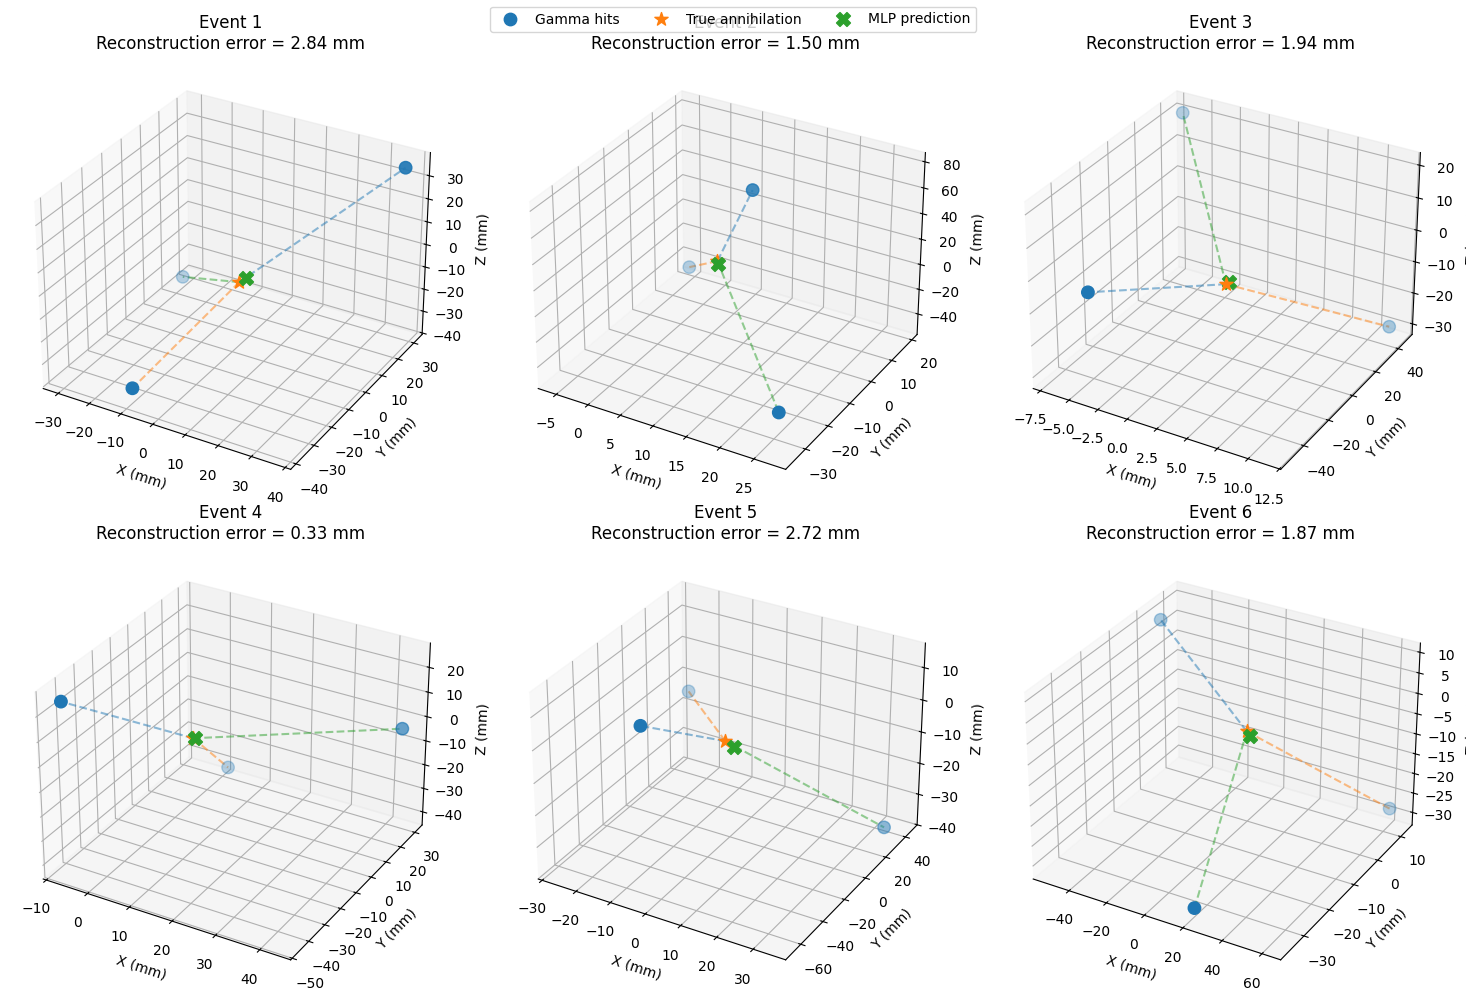

In [24]:
n_events = min(6, len(X_test_plane2d))

fig = plt.figure(figsize=(15, 10))

for i in range(n_events):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    # Use X_test_plane2d for features
    hits = np.array([X_test_plane2d[i, 0:3], X_test_plane2d[i, 4:7], X_test_plane2d[i, 8:11]])
    # Use y_test_plane2d for true positions
    true_pos = y_test_plane2d[i]
    # Use xyz_pred_plane2d for predicted positions
    pred_pos = xyz_pred_plane2d[i]

    ax.scatter(hits[:, 0], hits[:, 1], hits[:, 2], s=80, marker="o", label="Gamma hits")
    ax.scatter(*true_pos, s=100, marker="*", label="True annihilation")
    ax.scatter(*pred_pos, s=100, marker="X", label="MLP prediction")

    for hit in hits:
        ax.plot([true_pos[0], hit[0]], [true_pos[1], hit[1]], [true_pos[2], hit[2]],
                linestyle="--", alpha=0.5)

    ax.plot([true_pos[0], pred_pos[0]], [true_pos[1], pred_pos[1]], [true_pos[2], pred_pos[2]],
            linestyle=":", linewidth=2)

    error = np.linalg.norm(pred_pos - true_pos)
    ax.set_title(f"Event {i+1}\nReconstruction error = {error:.2f} mm")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

In [25]:
df_subset["EnergyDeposit_keV_true"] = df_subset["EnergyDeposit_keV"]
df_subset["EnergyDeposit_keV"] = df_subset["EnergyDeposit_keV"].apply(smear_energy)

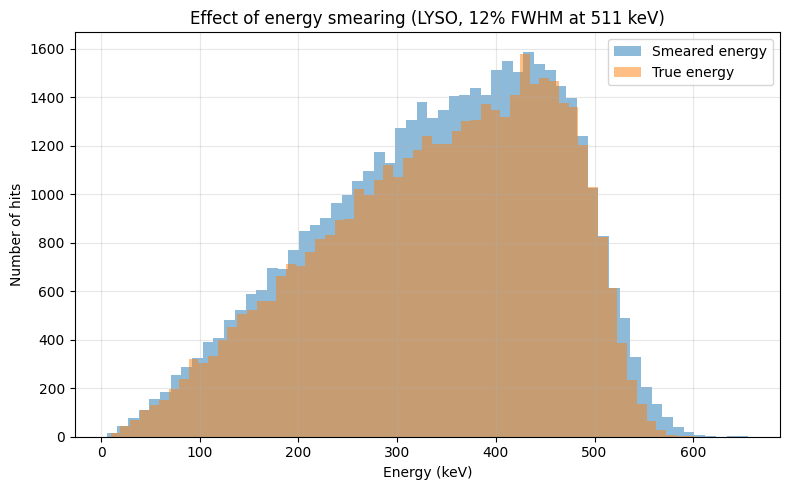

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(df_subset["EnergyDeposit_keV"], bins=60, alpha=0.5, label="Smeared energy")
plt.hist(df_subset["EnergyDeposit_keV_true"], bins=60, alpha=0.5, label="True energy")
plt.xlabel("Energy (keV)")
plt.ylabel("Number of hits")
plt.title("Effect of energy smearing (LYSO, 12% FWHM at 511 keV)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

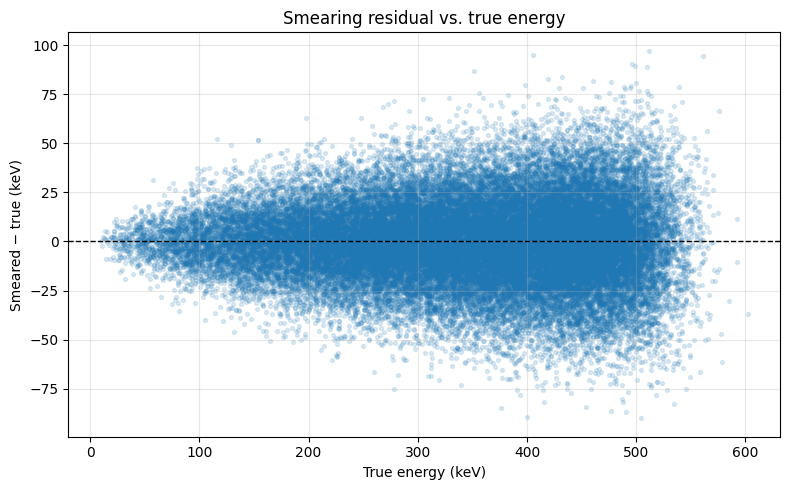

Energy range (keV)    Empirical σ    Theoretical σ  
10–94          9.45           8.31           
94–179          14.05          13.46          
179–264          17.28          17.14          
264–348          20.18          20.15          
348–433          22.90          22.77          
433–518          24.94          25.11          
518–602          27.14          27.26          


In [28]:
residual = df_subset["EnergyDeposit_keV"] - df_subset["EnergyDeposit_keV_true"]

plt.figure(figsize=(8, 5))
plt.scatter(df_subset["EnergyDeposit_keV_true"], residual, alpha=0.15, s=8)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("True energy (keV)")
plt.ylabel("Smeared − true (keV)")
plt.title("Smearing residual vs. true energy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Empirical vs theoretical sigma in a few energy bins, as a sanity check
bins = np.linspace(df_subset["EnergyDeposit_keV_true"].min(),
                    df_subset["EnergyDeposit_keV_true"].max(), 8)
bin_idx = np.digitize(df_subset["EnergyDeposit_keV_true"], bins)

print(f"{'Energy range (keV)':<22}{'Empirical σ':<15}{'Theoretical σ':<15}")
for b in range(1, len(bins)):
    mask = bin_idx == b
    if mask.sum() < 10:
        continue
    e_mid = (bins[b-1] + bins[b]) / 2
    empirical_sigma = residual[mask].std()
    theoretical_sigma = (LYSO_FWHM_AT_511 * REFERENCE_ENERGY_KEV
                          * np.sqrt(e_mid / REFERENCE_ENERGY_KEV) / FWHM_TO_SIGMA)
    print(f"{bins[b-1]:.0f}–{bins[b]:.0f}{'':<10}{empirical_sigma:<15.2f}{theoretical_sigma:<15.2f}")

                              Mean 3D error (mm)  Median 3D error (mm)
Condition                                                             
Ideal (no smearing)                     0.303000              0.224000
Smeared (12% FWHM @ 511 keV)            2.207434              1.979711


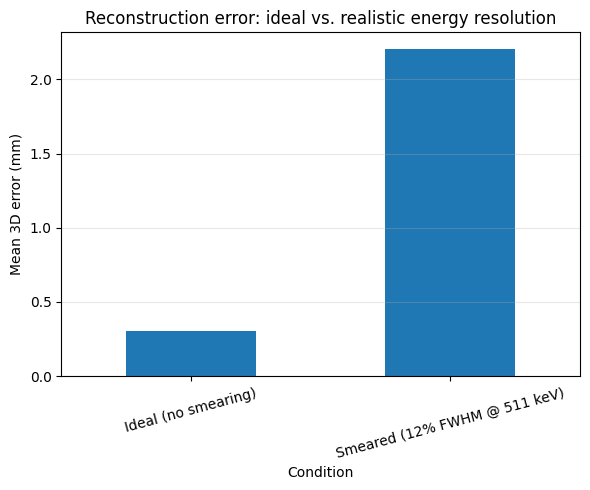

In [29]:
# Fill in from your unsmeared opening_energies_finetuning.ipynb run
ideal_mean_error = 0.303      # mm
ideal_median_error = 0.224    # mm
ideal_r2 = (0.982, 0.985, 0.987)  # X, Y, Z

comparison_rows = [
    {"Condition": "Ideal (no smearing)", "Mean 3D error (mm)": ideal_mean_error,
     "Median 3D error (mm)": ideal_median_error},
    {"Condition": "Smeared (12% FWHM @ 511 keV)", "Mean 3D error (mm)": mean_error_plane2d,
     "Median 3D error (mm)": median_error_plane2d},
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Condition")
print(comparison_df)

comparison_df["Mean 3D error (mm)"].plot(kind="bar", figsize=(6, 5),
                                           title="Reconstruction error: ideal vs. realistic energy resolution")
plt.ylabel("Mean 3D error (mm)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Smeared model — per-axis performance:
  X MAE: 1.118 mm   R²: 0.464
  Y MAE: 1.143 mm   R²: 0.631
  Z MAE: 1.063 mm   R²: 0.418

                               Mean 3D error (mm)  Median 3D error (mm)  \
Condition                                                                
Ideal (no smearing)                     0.303000              0.224000   
Smeared (12% FWHM @ 511 keV)            2.207434              1.979711   

                              X MAE (mm)  Y MAE (mm)  Z MAE (mm)  
Condition                                                         
Ideal (no smearing)             0.157000    0.155000    0.142000  
Smeared (12% FWHM @ 511 keV)    1.117591    1.143042    1.062868  


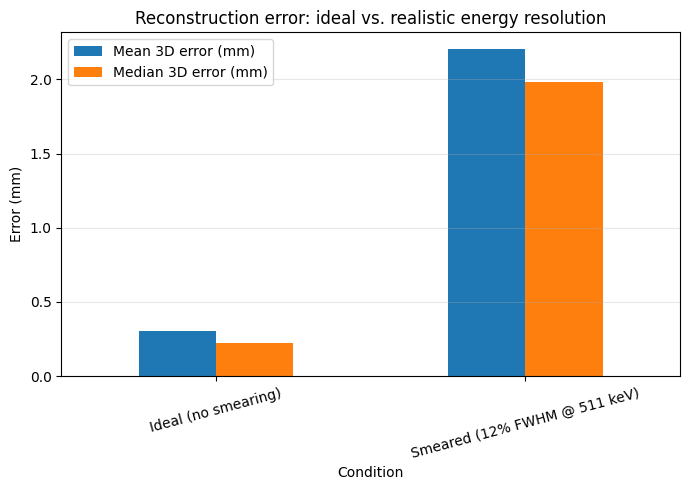

In [35]:
# Per-axis MAE and R² for the smeared model
print("Smeared model — per-axis performance:")
print(f"  X MAE: {x_mae_plane2d:.3f} mm   R²: {r2_score(y_test_plane2d[:, 0], xyz_pred_plane2d[:, 0]):.3f}")
print(f"  Y MAE: {y_mae_plane2d:.3f} mm   R²: {r2_score(y_test_plane2d[:, 1], xyz_pred_plane2d[:, 1]):.3f}")
print(f"  Z MAE: {z_mae_plane2d:.3f} mm   R²: {r2_score(y_test_plane2d[:, 2], xyz_pred_plane2d[:, 2]):.3f}")

# Full ideal-vs-smeared comparison table
comparison_rows = [
    {"Condition": "Ideal (no smearing)",
     "Mean 3D error (mm)": 0.303, "Median 3D error (mm)": 0.224,
     "X MAE (mm)": 0.157, "Y MAE (mm)": 0.155, "Z MAE (mm)": 0.142},
    {"Condition": "Smeared (12% FWHM @ 511 keV)",
     "Mean 3D error (mm)": mean_error_plane2d, "Median 3D error (mm)": median_error_plane2d,
     "X MAE (mm)": x_mae_plane2d, "Y MAE (mm)": y_mae_plane2d, "Z MAE (mm)": z_mae_plane2d},
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Condition")
print("\n", comparison_df)

comparison_df[["Mean 3D error (mm)", "Median 3D error (mm)"]].plot(
    kind="bar", figsize=(7, 5),
    title="Reconstruction error: ideal vs. realistic energy resolution"
)
plt.ylabel("Error (mm)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
for coordinate, index in [("X", 0), ("Y", 1), ("Z", 2)]:
    std = np.std(y_test_plane2d[:, index])
    print(f"{coordinate}: true value std = {std:.3f} mm")

X: true value std = 2.026 mm
Y: true value std = 2.540 mm
Z: true value std = 1.851 mm
